In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import logging
import os
import warnings
import itertools
from datetime import datetime, timedelta
from functools import partial
from pathlib import Path
from optimization_engines import (
    equal_weights_baseline, 
    genetic_algorithm_qubo, 
    scipy_slsqp_qubo, 
    riskfolio_qubo,
    dwave_cqm_qubo,
)

# Load D-Wave API token from .env file
from dotenv import load_dotenv
load_dotenv()

SEED = 12
np.random.seed(SEED)
msg_level = logging.INFO
# Suppress all RuntimeWarnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

## QUBO Portfolio Optimization using D-Wave Quantum Solver

In [2]:
# Create a logger
logger = logging.getLogger("inspect_results_logger")
logger.setLevel(msg_level)  # Set the level for this logger

# Create a handler (where to send the logs)
handler = logging.StreamHandler()  # Send to the console
handler.setLevel(msg_level)

# Create a formatter (how to format the logs)
formatter = logging.Formatter("%(asctime)s - %(name)s - %(levelname)s - %(message)s")
handler.setFormatter(formatter)

# Add the handler to the logger
logger.addHandler(handler)

### Path definition

In [3]:
benchmark_path = '../../data/benchmark_gspc.pkl'
source_path = '../../data/stocks_adjclose.pkl'

### Data loading

Ticker,ds,^GSPC
0,2011-01-03,1271.869995
1,2011-01-04,1270.199951
2,2011-01-05,1276.560059
3,2011-01-06,1273.849976
4,2011-01-07,1271.500000


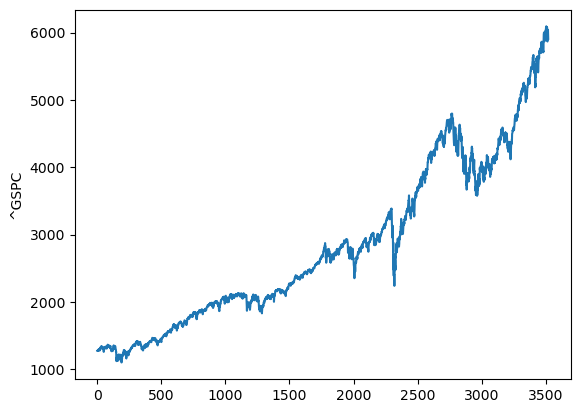

In [4]:
benchmark = pd.read_pickle(benchmark_path)
sns.lineplot(benchmark['^GSPC'])
benchmark.head()

In [5]:
source = pd.read_pickle(source_path)
print(source.shape)
# Check if any row contains at least one NaN
#print(source_wide.isnull().any(axis=1))
# Check if any value in the DataFrame is null
has_any_nan = source.isnull().values.any()
print("Any NaN in source_wide:", has_any_nan)
source.head()

(3522, 439)
Any NaN in source_wide: False


Ticker,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,WRB,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
ds,,,,,,,,,,,,,,,,,,,,,
2011-01-03,26.781836,9.917951,16.942663,9.349445,37.585785,31.290001,27.436106,20.712511,29.848969,39.270000,...,6.112024,18.971697,71.104691,11.828708,76.192101,14.700940,43.098133,26.977388,47.841393,38.200001
2011-01-04,26.532440,9.969709,17.102097,9.291334,37.338249,31.510000,27.125227,20.698887,29.741137,38.529999,...,6.072278,18.631702,69.911537,11.702991,78.568939,14.763333,43.300457,26.565216,47.206047,37.840000
2011-01-05,26.474880,10.051261,17.102097,9.305071,37.346004,32.220001,27.183071,20.794275,30.216925,41.240002,...,6.045782,18.713308,70.882263,12.068158,79.582596,14.675976,43.184826,26.691620,47.240875,37.799999
2011-01-06,26.526041,10.043136,17.066668,9.179339,37.485237,32.270000,27.334898,21.591436,30.451658,41.259998,...,5.977333,18.577297,71.084503,11.984348,80.162842,14.663502,43.462337,26.878460,45.778728,37.480000
2011-01-07,26.615564,10.115060,17.137522,9.109608,37.547104,32.040001,27.175838,21.768579,30.521458,40.759998,...,5.939793,18.486635,70.963158,12.313586,83.001091,14.794533,43.699345,27.213682,45.770027,37.599998


### Correlation Analysis

* Determine a set of stocks with minimal correlation

In [6]:
df_corr = source.corr()
df_corr.head()

Ticker,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,WRB,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
Ticker,,,,,,,,,,,,,,,,,,,,,
A,1.000000,0.938434,0.972057,0.803930,0.973666,0.944446,0.958391,0.877209,0.950709,0.946486,...,0.915526,0.962450,0.952409,0.840455,-0.192150,0.925082,0.581125,0.957106,0.742547,0.926361
AAPL,0.938434,1.000000,0.925958,0.904199,0.965640,0.912658,0.974905,0.858673,0.957237,0.883810,...,0.954041,0.944027,0.944347,0.799052,-0.274004,0.864298,0.709763,0.932155,0.609996,0.834967
ABT,0.972057,0.925958,1.000000,0.780764,0.974008,0.966874,0.947089,0.840192,0.947416,0.967112,...,0.905557,0.957242,0.959083,0.826124,-0.199613,0.959269,0.502779,0.961910,0.787986,0.938066
ACGL,0.803930,0.904199,0.780764,1.000000,0.859009,0.772929,0.921957,0.746998,0.908116,0.731481,...,0.943648,0.783657,0.889515,0.726342,-0.175307,0.746701,0.854873,0.878777,0.539229,0.617688
ACN,0.973666,0.965640,0.974008,0.859009,1.000000,0.962718,0.975225,0.861665,0.975261,0.940212,...,0.947315,0.970085,0.967641,0.856489,-0.227554,0.926912,0.623003,0.971591,0.727454,0.899654


#### Rank correlation ascending

In [7]:
# rank by correlation
corr_sum = df_corr.map(lambda x: abs(x)).sum()
corr_rank = corr_sum.sort_values().rank(method='min').astype(int)
corr_rank

Ticker
TPR       1
BKR       2
GE        3
WYNN      4
DVN       5
       ... 
TXN     435
TEL     436
ITW     437
ICE     438
HD      439
Length: 439, dtype: int64

#### Rank returns descending

In [8]:
# rank by returns
return_rank = source.diff().sum(axis=0).sort_values().rank(method='min', ascending=False).astype(int)
return_rank

Ticker
APA     439
MOS     438
SLB     437
DVN     436
PCG     435
       ... 
TDG       5
FICO      4
AZO       3
BKNG      2
NVR       1
Length: 439, dtype: int64

### Portfolio Stats

#### Select sets of 10 and 100 stocks with maximal returns and minimal correlation

In [9]:
select_10 = (return_rank + corr_rank).sort_values().reset_index()['Ticker'].values[:11]
select_10

array(['FICO', 'LLY', 'MCK', 'CHTR', 'GWW', 'AXON', 'REGN', 'RCL', 'RL',
       'TSLA', 'TPL'], dtype=object)

In [10]:
select_100 = (return_rank + corr_rank).sort_values().reset_index()['Ticker'].values[:101]
select_100

array(['FICO', 'LLY', 'MCK', 'CHTR', 'GWW', 'AXON', 'REGN', 'RCL', 'RL',
       'TSLA', 'TPL', 'MKTX', 'PWR', 'URI', 'TRGP', 'ZBRA', 'KLAC',
       'NFLX', 'ALGN', 'HUBB', 'AVGO', 'IBM', 'GE', 'BA', 'SPG', 'PH',
       'GNRC', 'ETN', 'BKNG', 'LULU', 'ERIE', 'DECK', 'AZO', 'WAB',
       'EXPE', 'CPAY', 'TDG', 'NVDA', 'BIIB', 'ULTA', 'TFX', 'SNPS',
       'MPWR', 'PODD', 'FDX', 'COST', 'LII', 'VRTX', 'TT', 'BLDR', 'MMM',
       'HUM', 'IT', 'CAT', 'ORLY', 'CAH', 'UAL', 'AMP', 'SBAC', 'UHS',
       'ESS', 'MHK', 'MTB', 'CDNS', 'GILD', 'EOG', 'WST', 'CRL', 'ADBE',
       'COR', 'GPN', 'GS', 'MSI', 'DIS', 'FFIV', 'JBL', 'IDXX', 'DE',
       'CLX', 'PGR', 'AJG', 'KKR', 'FRT', 'ADSK', 'DVA', 'VRSN', 'ANSS',
       'HES', 'XOM', 'CVX', 'MSCI', 'IRM', 'POOL', 'ISRG', 'INCY', 'TTWO',
       'NVR', 'COP', 'LIN', 'BDX', 'FIS'], dtype=object)

Defining Fitness Function for the calculation of Sharpe Ratio. I am using the Portfolio Variance as 

Portfolio variance = w12σ12 + w22σ22 + 2w1w2Cov1,2

In [11]:
def portfolio_stats(weights, data):

    weights = np.array(weights)
    returns = np.log(data) - np.log(data.shift(1)) # log return to minimize fp error
    # CONSISTENT: Always use log returns, never pct_change()
    port_return = np.sum(returns.mean() * weights) 
    port_vol = np.sqrt(np.dot(weights.T, np.dot(returns.cov() , weights)))
    try:
        sharpe_ratio = port_return/port_vol
    except Exception as e:
        sharpe_ratio = 0
    return sharpe_ratio, port_return, port_vol

### Data generator

Data generator to instantiate blocks on demand

In [12]:
def generate_data(df, benchmark, days_to_avg=30, days_to_opt=30, seed=SEED):
    df2 = df.reset_index()
    benchmark2 = benchmark.reset_index()
    elements = df2.sample(n=100, random_state=seed).index # definint a maximum of 100 different sampled initial dates
    for idx in elements:
        df_sample = df2.iloc[idx-days_to_avg:idx+days_to_opt, :]
        df_sample = df_sample.set_index('ds')
        df_sample_b = benchmark2.iloc[idx-days_to_avg:idx+days_to_opt, :]
        df_sample_b = df_sample_b.set_index('ds').drop(['index'], axis=1)
        yield df_sample, df_sample_b

### Backtest

In [13]:
def backtest(optimization_function, data, benchmark, initial_capital, avg_period, opt_period):
    portfolio_value = initial_capital
    portfolio_returns = []
    benchmark_returns = []
    portfolio_total_return = []
    portfolio_sharpe_ratios = []
    weights_history = pd.DataFrame(index=data.index, columns=data.columns)
    portfolio_value_history = pd.Series(index=data.index, name='Portfolio Value', dtype='float')
    portfolio_value_history.iloc[0] = portfolio_value


    j = 0
    for i in range(avg_period+1, avg_period + opt_period+1):
        df = data.iloc[j:i, :]
        # Use log returns for consistency with optimization functions
        df_log_returns = np.log(df) - np.log(df.shift(1))
        df_log_returns = df_log_returns.dropna(axis=0)
        #logger.debug(f'df_log_returns: {df_log_returns}')
        weights = optimization_function(df)
        weights[weights < 0] = 0
        weights /= weights.sum()
        weights_history.loc[df.index[-1]] = weights
        #sharpe_ratio, portfolio_return, portfolio_volatility = portfolio_stats(weights, df)
        # portfolio_change = df.iloc[-2:, :].pct_change() * weights
        portfolio_change = df_log_returns.iloc[-1] * weights
        #portfolio_return = portfolio_change.sum(axis=1).iloc[-1]
        portfolio_return = portfolio_change.sum()
        portfolio_returns.append(portfolio_return)
        # print(f'portfolio returns: {portfolio_returns}')
        # Use log returns for benchmark as well
        benchmark_log_returns = np.log(benchmark.iloc[j:i, :]) - np.log(benchmark.iloc[j:i, :].shift(1))
        benchmark_return = benchmark_log_returns.iloc[-1].values.tolist()[0]
        benchmark_returns.append(benchmark_return)
        # print(f'benchmark_returns: {benchmark_returns}')
        portfolio_cumulative_returns = np.cumprod([k + 1 for k in portfolio_returns])
        # print(f'portfolio cumulative returns: {portfolio_cumulative_returns}')
        benchmark_cumulative_returns = np.cumprod([k + 1 for k in  benchmark_returns])
        # print(f'benchmark cumulative returns: {benchmark_cumulative_returns}')
        portfolio_mean_return = np.mean(portfolio_returns)
        benchmark_mean_return = np.mean(benchmark_returns)
        portfolio_volatility = np.std(portfolio_returns) 
        benchmark_volatility = np.std(benchmark_returns)
        try:
            sharpe_ratio = (portfolio_mean_return) / portfolio_volatility
        except Exception as e:
            sharpe_ratio = 0
        portfolio_sharpe_ratios.append(sharpe_ratio)

         # Portfolio & Benchmark value
        benchmark_value = initial_capital * benchmark_cumulative_returns[-1]
        portfolio_value = initial_capital * portfolio_cumulative_returns[-1]
        j += 1

    portfolio_cumulative_returns = portfolio_cumulative_returns - portfolio_cumulative_returns[0]
    benchmark_cumulative_returns = benchmark_cumulative_returns - benchmark_cumulative_returns[0]

    # Plot the results
    plt.figure(figsize=(12, 6))
    plt.plot(portfolio_cumulative_returns, label='Portfolio')
    plt.plot(benchmark_cumulative_returns, label='Benchmark')
    #plt.plot(portfolio_returns, label='Portfolio')
    #plt.plot(benchmark_returns, label='Benchmark')
    plt.legend(loc='upper left')
    plt.title('Backtesting Results')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Returns')
    plt.show()

    return weights_history, portfolio_value_history, portfolio_cumulative_returns, benchmark_cumulative_returns

In [14]:
import pickle

def write_pickle_dict(data, file_path):
    """Pickles a dictionary and saves it to a file."""
    try:
        with open(file_path, 'wb') as f:  # Open the file in binary write mode ('wb')
            pickle.dump(data, f)
        print(f"Dictionary pickled and saved to {file_path}")
    except Exception as e:
        print(f"An error occurred while pickling: {e}")

def read_pickle_dict(file_path):
    try:
        with open(file_path, 'rb') as f:
            loaded_dict = pickle.load(f)
    except FileNotFoundError:
        print(f"Error: File '{file_path}' not found.")
    except Exception as e:
        print(f"An error occurred: {e}")
    return loaded_dict

### Run Experiment Function

In [15]:
def run_experiment(results_path_template, data, benchmark, opt_fun, parameters):

    n_periods = parameters['n_periods']
    days_to_avg = parameters['days_to_avg']
    days_to_opt = parameters['days_to_opt']
    initial_capital = parameters['initial_capital']
    datagen = generate_data(data, benchmark)

        
    for i in range(n_periods):
        results_path = results_path_template.format(i)
        if not os.path.exists(results_path):
            try:
                df, df_b = next(datagen)
                print(f'initial date: {df.iloc[days_to_avg+1:, :].index[0]}')
                plt.figure(figsize=(12, 6))
                plt.plot(df.iloc[days_to_avg+1:days_to_avg+days_to_opt+1, :].sum(axis=1), label='Source')
                plt.plot(df_b, label='Benchmark')
                plt.legend(loc='upper left')
                plt.title('Source Data')
                plt.xlabel('Date')
                plt.ylabel('Stock Values')
                plt.show()
                start_time = datetime.now()
                weights_history, portfolio_value_history, portfolio_cumulative_returns, benchmark_cumulative_returns = backtest(opt_fun, df, df_b, initial_capital=initial_capital, avg_period=days_to_avg,opt_period=days_to_opt)
                logger.debug(f'portfolio cumulative returns: {portfolio_cumulative_returns}')
                end_time = datetime.now()
                dt = abs(end_time - start_time)
            except Exception as e: 
                print(f'Failed {results_path} due to {e}')
                weights_history, portfolio_value_history, portfolio_cumulative_returns, benchmark_cumulative_returns = [], [], [], []

            result = {
                "round": i, 
                "start_date": df.index[0],
                "end_date": df.index[-1],
                "days_to_avg": days_to_avg,
                "days_to_opt": days_to_opt,
                "weights_history": weights_history,
                "portfolio_value_history": portfolio_value_history,
                "portfolio_cumulative_returns": portfolio_cumulative_returns,
                "benchmark_cumulative_returns": benchmark_cumulative_returns,
                "total_run_time": dt.total_seconds()
                }
            write_pickle_dict(result, results_path)

        else:
            results = read_pickle_dict(results_path)
            portfolio_cumulative_returns = results['portfolio_cumulative_returns']
            benchmark_cumulative_returns = results['benchmark_cumulative_returns']

            # Plot the results
            plt.figure(figsize=(12, 6))
            plt.plot(portfolio_cumulative_returns, label='Portfolio')
            plt.plot(benchmark_cumulative_returns, label='Benchmark')
            plt.legend(loc='upper left')
            plt.title('Backtesting Results')
            plt.xlabel('Date')
            plt.ylabel('Cumulative Returns')
            plt.show()
            
    return None

### Performance Analysis Functions

In [16]:
def performance_summary(solver_configs, n_periods):
    """Generate performance summary across all periods for multiple solvers."""
    summary_data = []
    
    for config in solver_configs:
        solver_name = config['name']
        path_template = config['path_template']
        
        returns_data = []
        execution_times = []
        successful_periods = 0
        
        for period in range(n_periods):
            file_path = path_template.format(period)
            try:
                result_data = read_pickle_dict(file_path)
                if result_data is not None:
                    portfolio_returns = result_data.get('portfolio_cumulative_returns', [])
                    execution_time = result_data.get('total_run_time', 0)
                    
                    # Safe check for portfolio returns data
                    try:
                        if portfolio_returns is not None and len(portfolio_returns) > 0:
                            final_return = portfolio_returns[-1]
                            returns_data.append(final_return)
                            execution_times.append(execution_time)
                            successful_periods += 1
                    except (TypeError, IndexError):
                        pass
            except Exception as e:
                logger.debug(f'Could not process {file_path}: {e}')
        
        if returns_data:
            summary_data.append({
                'Solver': solver_name,
                'Periods': successful_periods,
                'Avg_Return': np.mean(returns_data),
                'Std_Return': np.std(returns_data),
                'Min_Return': np.min(returns_data),
                'Max_Return': np.max(returns_data),
                'Avg_Time': np.mean(execution_times),
                'Std_Time': np.std(execution_times),
                'Success_Rate': successful_periods / n_periods * 100
            })
    
    if summary_data:
        df = pd.DataFrame(summary_data)
        df = df.round(4)
        return df
    else:
        return pd.DataFrame()

### Global Parameters

QUBO-specific parameters for quantum optimization

In [17]:
parameters = {
    "n_periods": 1,
    "days_to_avg": 30,
    "days_to_opt": 30,
    "initial_capital": 1_000_000,
    "budget": 1000000.0,
}

### Test 1: D-Wave CQM QUBO Optimization with Full Dataset

In [25]:
# D-Wave CQM QUBO Optimization - Define the optimization function
opt_fun_dwave_cqm = partial(dwave_cqm_qubo, budget=parameters["budget"])

# Extract n_periods for use in performance analysis
n_periods = parameters['n_periods']

print(f"D-Wave CQM QUBO optimization function created with parameters:")
# print(f"  budget: {parameters['budget']}")
print(f"  n_periods: {n_periods}")

D-Wave CQM QUBO optimization function created with parameters:
  n_periods: 1


In [19]:
# results_path_dwave_cqm_full = '../../results/qubo/results_full_{}_dwave_cqm.pkl'
# _ = run_experiment(results_path_dwave_cqm_full, source, benchmark, opt_fun_dwave_cqm, parameters)

#### Performance Analysis for D-Wave CQM Full Dataset

In [20]:
# # Performance analysis for D-Wave CQM QUBO optimization (Full Dataset)
# dwave_cqm_full_solvers = [
#     {'path_template': '../../results/qubo/results_full_{}_dwave_cqm.pkl', 'name': 'D-Wave CQM QUBO'},
# ]

# print("\n" + "="*100)
# print("COMPREHENSIVE PERFORMANCE SUMMARY - D-Wave CQM QUBO Optimization (Full Dataset)")
# print("="*100)
# summary_df = performance_summary(dwave_cqm_full_solvers, n_periods)
# if not summary_df.empty:
#     display(summary_df)
    
#     # Performance analysis
#     print("\nPerformance Analysis:")
#     print("-" * 50)
#     print(f"Successful periods: {summary_df.iloc[0]['Periods']}/{n_periods}")
#     print(f"Average return: {summary_df.iloc[0]['Avg_Return']:.4f}")
#     print(f"Average execution time: {summary_df.iloc[0]['Avg_Time']:.2f}s")
#     print(f"Success rate: {summary_df.iloc[0]['Success_Rate']:.1f}%")
# else:
#     print("No summary data available")

## Test 6: Wide Dataset (Stocks + ETFs)

In [21]:
source_path_extended = '../../data/etfs_close.pkl'

In [22]:
source_extended = pd.read_pickle(source_path_extended)
source_extended.head()

Ticker,ds,AADR,ACWI,ACWX,AFG,AGG,AMLP,BIL,BIV,BND,...,XLP,XLU,XLV,XLY,XME,XOP,XPH,XRT,XSD,XTNT
0,2011-01-03,26.494179,35.018154,30.182961,14.173727,71.489235,26.573900,76.281036,50.488926,53.083935,...,19.910189,19.169912,24.896574,31.685013,57.138588,168.841461,17.785585,19.920353,25.601683,1074.0
1,2011-01-04,26.450108,34.981026,30.019852,14.104879,71.509521,26.491484,76.281036,50.562424,53.090553,...,19.855919,19.261232,24.974888,31.509201,56.714920,167.352570,17.651617,19.548199,25.860556,1032.0
2,2011-01-05,26.291458,34.981026,29.992662,14.066156,71.164383,26.458506,76.281036,50.188774,52.858776,...,19.862703,19.139469,25.029711,31.768719,57.097866,167.922791,17.774096,19.531855,26.151806,1050.0
3,2011-01-06,26.291458,34.758274,29.727602,14.264087,71.177925,26.458506,76.281036,50.378658,52.905167,...,19.794865,19.157736,25.131519,31.576189,56.389015,167.099167,17.873608,19.253756,26.558626,1026.0
4,2011-01-07,26.150438,34.632030,29.578085,14.195246,71.408035,26.491484,76.264374,50.678814,53.103794,...,19.693110,19.224695,25.115862,31.559439,56.112007,167.701004,17.892746,19.196499,26.697304,1050.0


In [23]:
source_wide = pd.merge(source, source_extended, on='ds', how='left').set_index('ds').dropna()
print(source_wide.shape)
# Check if any row contains at least one NaN
#print(source_wide.isnull().any(axis=1))
# Check if any value in the DataFrame is null
has_any_nan = source_wide.isnull().values.any()
print("Any NaN in source_wide:", has_any_nan)
source_wide.head()

(3521, 680)
Any NaN in source_wide: False


Ticker,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,XLP,XLU,XLV,XLY,XME,XOP,XPH,XRT,XSD,XTNT
ds,,,,,,,,,,,,,,,,,,,,,
2011-01-03,26.781836,9.917951,16.942663,9.349445,37.585785,31.290001,27.436106,20.712511,29.848969,39.270000,...,19.910189,19.169912,24.896574,31.685013,57.138588,168.841461,17.785585,19.920353,25.601683,1074.0
2011-01-04,26.532440,9.969709,17.102097,9.291334,37.338249,31.510000,27.125227,20.698887,29.741137,38.529999,...,19.855919,19.261232,24.974888,31.509201,56.714920,167.352570,17.651617,19.548199,25.860556,1032.0
2011-01-05,26.474880,10.051261,17.102097,9.305071,37.346004,32.220001,27.183071,20.794275,30.216925,41.240002,...,19.862703,19.139469,25.029711,31.768719,57.097866,167.922791,17.774096,19.531855,26.151806,1050.0
2011-01-06,26.526041,10.043136,17.066668,9.179339,37.485237,32.270000,27.334898,21.591436,30.451658,41.259998,...,19.794865,19.157736,25.131519,31.576189,56.389015,167.099167,17.873608,19.253756,26.558626,1026.0
2011-01-07,26.615564,10.115060,17.137522,9.109608,37.547104,32.040001,27.175838,21.768579,30.521458,40.759998,...,19.693110,19.224695,25.115862,31.559439,56.112007,167.701004,17.892746,19.196499,26.697304,1050.0


#### D-Wave CQM QUBO Optimization - Wide Dataset

initial date: 2014-01-13 00:00:00


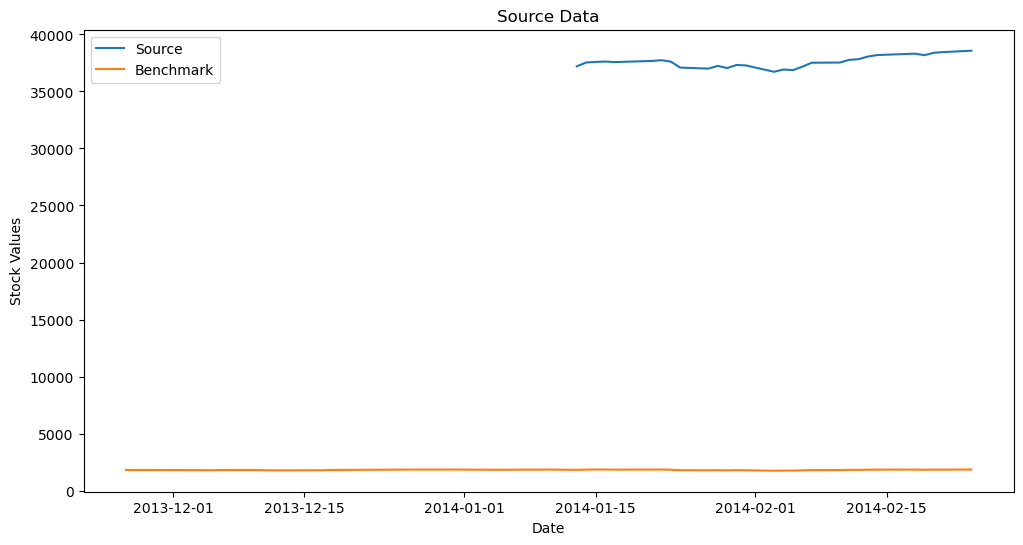

2025-09-10 21:20:11,177 - inspect_results_logger - INFO - n samples: 91
2025-09-10 21:24:43,863 - inspect_results_logger - INFO - n samples: 87
2025-09-10 21:29:13,350 - inspect_results_logger - INFO - n samples: 88
2025-09-10 21:33:46,395 - inspect_results_logger - INFO - n samples: 83
2025-09-10 21:38:23,868 - inspect_results_logger - INFO - n samples: 84
2025-09-10 21:42:58,599 - inspect_results_logger - INFO - n samples: 87
2025-09-10 21:47:33,775 - inspect_results_logger - INFO - n samples: 82
2025-09-10 21:52:11,171 - inspect_results_logger - INFO - n samples: 101
2025-09-10 21:56:52,008 - inspect_results_logger - INFO - n samples: 100
2025-09-10 22:01:31,971 - inspect_results_logger - INFO - n samples: 86
2025-09-10 22:06:03,352 - inspect_results_logger - INFO - n samples: 105
2025-09-10 22:10:39,147 - inspect_results_logger - INFO - n samples: 86


In [ ]:
results_path_dwave_cqm_wide = '../../results/qubo/results_wide_{}_dwave_cqm.pkl'
_ = run_experiment(results_path_dwave_cqm_wide, source_wide, benchmark, opt_fun_dwave_cqm, parameters)

#### Performance Analysis for Wide Dataset

In [ ]:
# Performance analysis for D-Wave CQM QUBO optimization (Wide Dataset - Stocks + ETFs)
dwave_cqm_wide_solvers = [
    {'path_template': '../../results/qubo/results_wide_{}_dwave_cqm.pkl', 'name': 'D-Wave CQM QUBO'},
]

print("\n" + "="*100)
print("COMPREHENSIVE PERFORMANCE SUMMARY - D-Wave CQM QUBO Optimization (Wide Dataset - Stocks + ETFs)")
print("="*100)
summary_df = performance_summary(dwave_cqm_wide_solvers, n_periods)
if not summary_df.empty:
    display(summary_df)
    
    # Performance analysis
    print("\nPerformance Analysis:")
    print("-" * 50)
    print(f"Successful periods: {summary_df.iloc[0]['Periods']}/{n_periods}")
    print(f"Average return: {summary_df.iloc[0]['Avg_Return']:.4f}")
    print(f"Average execution time: {summary_df.iloc[0]['Avg_Time']:.2f}s")
    print(f"Success rate: {summary_df.iloc[0]['Success_Rate']:.1f}%")
else:
    print("No summary data available")

## Overall QUBO Performance Summary

In [ ]:
# Compare all QUBO optimization methods
all_qubo_solvers = [
    {'path_template': '../../results/qubo_optimization/results_full_{}_dwave_cqm.pkl', 'name': 'D-Wave CQM QUBO'},
    {'path_template': '../../results/qubo_optimization/results_full_{}_genetic.pkl', 'name': 'Genetic Algorithm QUBO'},
    {'path_template': '../../results/qubo_optimization/results_full_{}_scipy.pkl', 'name': 'SciPy SLSQP QUBO'},
    {'path_template': '../../results/qubo_optimization/results_full_{}_equal_weights.pkl', 'name': 'Equal Weights Baseline'},
    {'path_template': '../../results/qubo_optimization/results_wide_{}_dwave_cqm.pkl', 'name': 'D-Wave CQM QUBO (Wide)'},
]

# Add riskfolio if available
if RISKFOLIO_AVAILABLE:
    all_qubo_solvers.append({'path_template': '../../results/qubo_optimization/results_full_{}_riskfolio.pkl', 'name': 'Riskfolio QUBO'})

print("\n" + "="*120)
print("OVERALL QUBO OPTIMIZATION PERFORMANCE COMPARISON - ALL METHODS")
print("="*120)

summary_df = performance_summary(all_qubo_solvers, n_periods)
if not summary_df.empty:
    # Sort by average return for better readability
    summary_df_sorted = summary_df.sort_values('Avg_Return', ascending=False)
    display(summary_df_sorted)
    
    # Performance analysis
    print("\nPerformance Analysis Across All QUBO Methods:")
    print("-" * 70)
    print(f"Best performing method: {summary_df_sorted.iloc[0]['Solver']} (avg return: {summary_df_sorted.iloc[0]['Avg_Return']:.4f})")
    print(f"Fastest execution: {summary_df.loc[summary_df['Avg_Time'].idxmin(), 'Solver']} ({summary_df['Avg_Time'].min():.2f}s)")
    print(f"Most reliable: {summary_df.loc[summary_df['Success_Rate'].idxmax(), 'Solver']} ({summary_df['Success_Rate'].max():.1f}% success rate)")
    
    # Method comparison
    print("\nMethod Comparison:")
    print("-" * 80)
    for _, row in summary_df_sorted.iterrows():
        dataset_info = "680 assets" if "Wide" in row['Solver'] else "439 assets"
        print(f"{row['Solver']:<25}: {dataset_info:>10} | {row['Avg_Time']:>8.2f}s | {row['Success_Rate']:>6.1f}% | {row['Avg_Return']:>8.4f}")
        
else:
    print("No summary data available")